# AI-Based Crowd Behavior Analysis and Anomalous Movement Tracking
# Smart Drones and Robots Final Project
# Ahtisham Khan


In [1]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.8 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import cv2
import math
import os
import re
from google.colab import files
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

print("Uploaded video:", video_path)

Saving Pedestrians Crossing the Road Stock Video.mp4 to Pedestrians Crossing the Road Stock Video.mp4
Uploaded video: Pedestrians Crossing the Road Stock Video.mp4


In [4]:
model = YOLO("yolov8n.pt")
print("YOLOv8 model loaded successfully")

YOLOv8 model loaded successfully


In [5]:
cap = cv2.VideoCapture(video_path)

print("Video opened:", cap.isOpened())
print("Width:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Height:", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
print("FPS:", cap.get(cv2.CAP_PROP_FPS))

cap.release()

Video opened: True
Width: 1280
Height: 720
FPS: 23.976023976023978


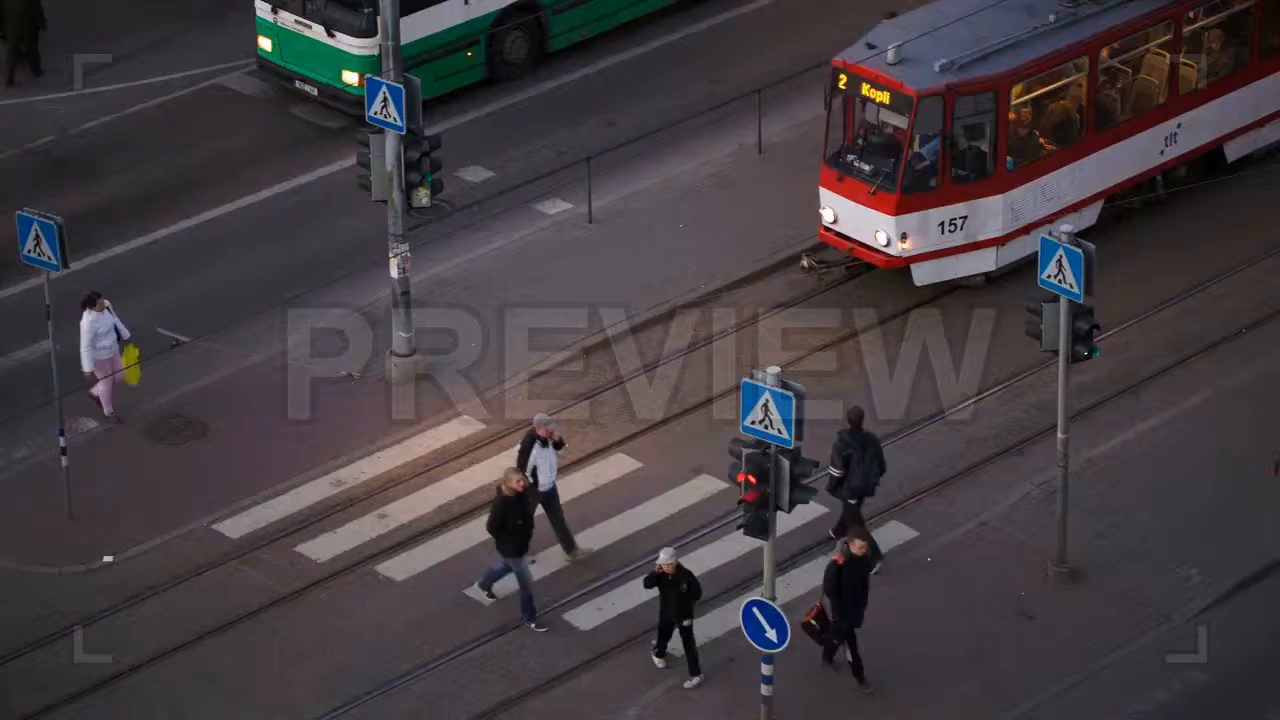

In [6]:
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    cv2_imshow(frame)

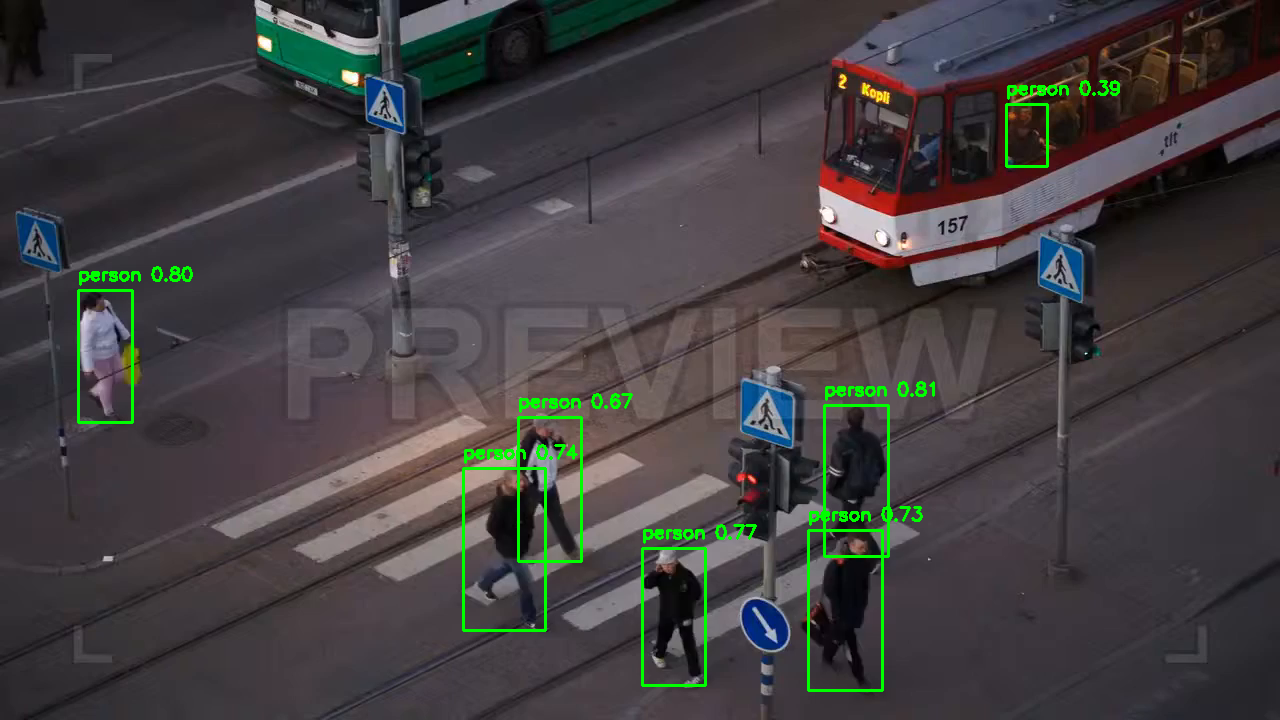

In [7]:
test_frame = frame.copy()

results = model(test_frame, verbose=False)[0]

for box in results.boxes:
    if int(box.cls[0]) == 0:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(test_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            test_frame,
            f"person {conf:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

cv2_imshow(test_frame)

In [8]:
cap = cv2.VideoCapture(video_path)

os.makedirs("final_ai_frames", exist_ok=True)

person_history = {}
risk_history = {}
selected_target_id = None

min_risk_threshold = 8
min_consistent_frames = 4
frame_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    results = model.track(
        frame,
        persist=True,
        classes=[0],
        verbose=False
    )

    boxes = results[0].boxes
    current_people = []

    if boxes.id is not None:
        ids = boxes.id.int().cpu().tolist()

        for box, track_id in zip(boxes, ids):
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2

            if track_id not in person_history:
                person_history[track_id] = {
                    "positions": [],
                    "speed": 0,
                    "dx": 0,
                    "dy": 0
                }

            history = person_history[track_id]

            dx = 0
            dy = 0
            speed = 0

            if len(history["positions"]) > 0:
                prev_x, prev_y = history["positions"][-1]

                dx = cx - prev_x
                dy = cy - prev_y
                speed = math.hypot(dx, dy)

            history["positions"].append((cx, cy))

            if len(history["positions"]) > 20:
                history["positions"].pop(0)

            history["speed"] = speed
            history["dx"] = dx
            history["dy"] = dy

            current_people.append({
                "id": track_id,
                "box": (x1, y1, x2, y2),
                "center": (cx, cy),
                "speed": speed,
                "dx": dx,
                "dy": dy,
                "risk": 0
            })

    if len(current_people) > 0:
        avg_speed = sum(p["speed"] for p in current_people) / len(current_people)
        avg_dx = sum(p["dx"] for p in current_people) / len(current_people)
        avg_dy = sum(p["dy"] for p in current_people) / len(current_people)

        for person in current_people:
            speed_score = abs(person["speed"] - avg_speed)
            direction_score = math.hypot(
                person["dx"] - avg_dx,
                person["dy"] - avg_dy
            )

            risk_score = speed_score + direction_score
            person["risk"] = risk_score

            track_id = person["id"]

            if track_id not in risk_history:
                risk_history[track_id] = 0

            if risk_score > min_risk_threshold:
                risk_history[track_id] += 1
            else:
                risk_history[track_id] = 0

        best_person = max(current_people, key=lambda p: p["risk"])

        if risk_history.get(best_person["id"], 0) >= min_consistent_frames:
            selected_target_id = best_person["id"]

    cv2.putText(
        frame,
        "AI Behavior Analysis Active",
        (20, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    for person in current_people:
        x1, y1, x2, y2 = person["box"]
        cx, cy = person["center"]

        color = (0, 255, 0)
        label = f"ID {person['id']} Risk {person['risk']:.1f}"

        if person["id"] == selected_target_id:
            color = (0, 0, 255)
            label = f"Selected Target ID {person['id']} Risk {person['risk']:.1f}"

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.circle(frame, (cx, cy), 5, (0, 0, 255), -1)
        cv2.putText(
            frame,
            label,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    cv2.imwrite(f"final_ai_frames/frame_{frame_count}.jpg", frame)
    frame_count += 1

cap.release()

print("Final AI behavior analysis complete")
print("Frames processed:", frame_count)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 403ms
Prepared 1 package in 90ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Final AI behavior analysis complete
Frames processed: 448


In [9]:
frame_folder = "final_ai_frames"
output_video = "final_ai_behavior_demo.mp4"

def frame_number(filename):
    return int(re.findall(r"\d+", filename)[0])

frame_files = sorted(os.listdir(frame_folder), key=frame_number)

first_frame = cv2.imread(os.path.join(frame_folder, frame_files[0]))
height, width, _ = first_frame.shape

out = cv2.VideoWriter(
    output_video,
    cv2.VideoWriter_fourcc(*"mp4v"),
    24,
    (width, height)
)

for frame_file in frame_files:
    frame = cv2.imread(os.path.join(frame_folder, frame_file))
    out.write(frame)

out.release()

print("Saved final video:", output_video)

Saved final video: final_ai_behavior_demo.mp4


In [11]:
files.download("final_ai_behavior_demo.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>